# 00_06 — Regresión AR(1) sobre Scores FPCA

**Objetivo:** Modelar la dinámica temporal de los scores FPCA mediante regresiones AR(1) independientes por componente.

**Pipeline completo:**

```
FAR(1) simulado  ──►  X ∈ ℝ^{T×G}
       ↓
B-spline + FPCA  ──►  Θ ∈ ℝ^{T×K}   (scores: θ_{t,k} para t=1,...,T  k=1,...,K)
       ↓
por componente k:
    θ_{t,k} = α_k + β_k · θ_{t-1,k} + ε_{t,k}  # Aqui se utiliza el modelo PBSP
       ↓
Evaluación: R², RMSE, diagnóstico de residuos
```

### Rutas del proyecto

| Rol | Ruta |
|-----|------|
| Datos simulados (train + test) | `data/simulaciones/raw/` |
| Predicciones AR(1) | `data/simulaciones/processed/predict/` |
| Reportes | `reports/simulaciones/` |

## 0. Imports y configuración de rutas

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from scipy import stats
from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.graphics         import plot_functional_time_series
from model_psbp_fd.models.psbp_fd_v1.psbp_fd_v1 import PSBP_FD_v1

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

# ── Raíz del proyecto ────────────────────────────────────────────────────────
def get_project_root(marker="README.md"):
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            print(f" PROJECT_ROOT: {parent}")
            return parent
    print(f" No se encontró '{marker}', usando directorio actual")
    return current

PROJECT_ROOT = get_project_root("README.md")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Rutas canónicas ───────────────────────────────────────────────────────────
PATHS = {
    "raw":     PROJECT_ROOT / "data" / "simulaciones" / "raw",
    "predict": PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict",
    "reports": PROJECT_ROOT / "reports" / "simulaciones",
}
for name, path in PATHS.items():
    print(f"  {name:10s} → {path}")

 PROJECT_ROOT: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
  raw        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  predict    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\predict
  reports    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones


## 1. Configuración del experimento

In [57]:
# ── Identificación ───────────────────────────────────────────────────────────
BASENAME      = "FAR_lineal_st"
TT            = 1
SEED          = 42
TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"ar1_scores_{BASENAME}_{TT}_{TIMESTAMP}"

print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed          : {SEED}")

# ── Parámetros del proceso FAR(1) ────────────────────────────────────────────
# Controlan la generación de las curvas X_t(s) — NO tocar entre experimentos
# de representación para mantener el proceso generador fijo.
FAR_PARAMS = {
    "n_curves":       150,    # T total de curvas (train + test)
    "n_points":       100,    # G: puntos de grilla en s ∈ [0,1]
    "bandwidth":      0.05,   # ancho del kernel gaussiano de Ψ
    "decay":          0.6,    # escala del operador integral (|λ|_max ≈ 0.55)
    "temporal_slope": 2.0,    # β_t: crecimiento de μ_t(s) entre curvas
    "spatial_slope":  2.0,    # β_s: crecimiento de μ_t(s) dentro de cada curva
    "intercept":      1.0,    # α: nivel base de la tendencia
    "noise_std":      0.5,    # std efectiva del ruido funcional ε_t
    "noise_type":     "smooth",
    "burn_in":        100,      # iteraciones de calentamiento del FAR(1)
}

# ── Parámetros de representación funcional ────────────────────────────────────
# Controlan cómo se proyectan las curvas X_t(s) → scores Θ_t.
# Se pueden variar independientemente de FAR_PARAMS.
REPRE_PARAMS = {
    "n_basis":      8,   # K intermedio: funciones B-spline de suavizado
    "n_basis_fpca": 3,   # K final: componentes FPCA retenidos
    "order":        5,    # orden del spline: 4 = cúbico (default). 3 = cuadrático, 5 = quíntico
}
K_fpca = REPRE_PARAMS["n_basis_fpca"]

# ── Hiperparámetros MCMC ──────────────────────────────────────────────────────
MCMC_CONFIG = {
    "nsim": 2000,
    "burn":  200,
    "N":    20,
    "M":    50,
}

# ── Hiperparámetros del modelo ────────────────────────────────────────────────
HYPERPARAMS = {
    "atau":    0.5,
    "btau":    0.5,
    "ag":      0.5,
    "bg":      0.5,
    "apij":    1.0,
    "bpij":    5.0,
    "mumu":    0.0,
    "taumu":   1.0,
    "mupsij":  0.0,
    "taupsij": 1.0,
    "pwj":     0.5,
}

print(f"\n── FAR_PARAMS ──")
for k, v in FAR_PARAMS.items():
    print(f"  {k:<18}: {v}")
print(f"\n── REPRE_PARAMS ──")
for k, v in REPRE_PARAMS.items():
    print(f"  {k:<18}: {v}")
print(f"\nK_fpca (componentes AR(1)) : {K_fpca}")

Experiment ID : ar1_scores_FAR_lineal_st_1_20260511_023042
Seed          : 42

── FAR_PARAMS ──
  n_curves          : 150
  n_points          : 100
  bandwidth         : 0.05
  decay             : 0.6
  temporal_slope    : 2.0
  spatial_slope     : 2.0
  intercept         : 1.0
  noise_std         : 0.5
  noise_type        : smooth
  burn_in           : 100

── REPRE_PARAMS ──
  n_basis           : 8
  n_basis_fpca      : 3
  order             : 5

K_fpca (componentes AR(1)) : 3


## 2. Simulación de datos 

Datos simulados : (150, 100)  →  T=150 curvas, G=100 puntos


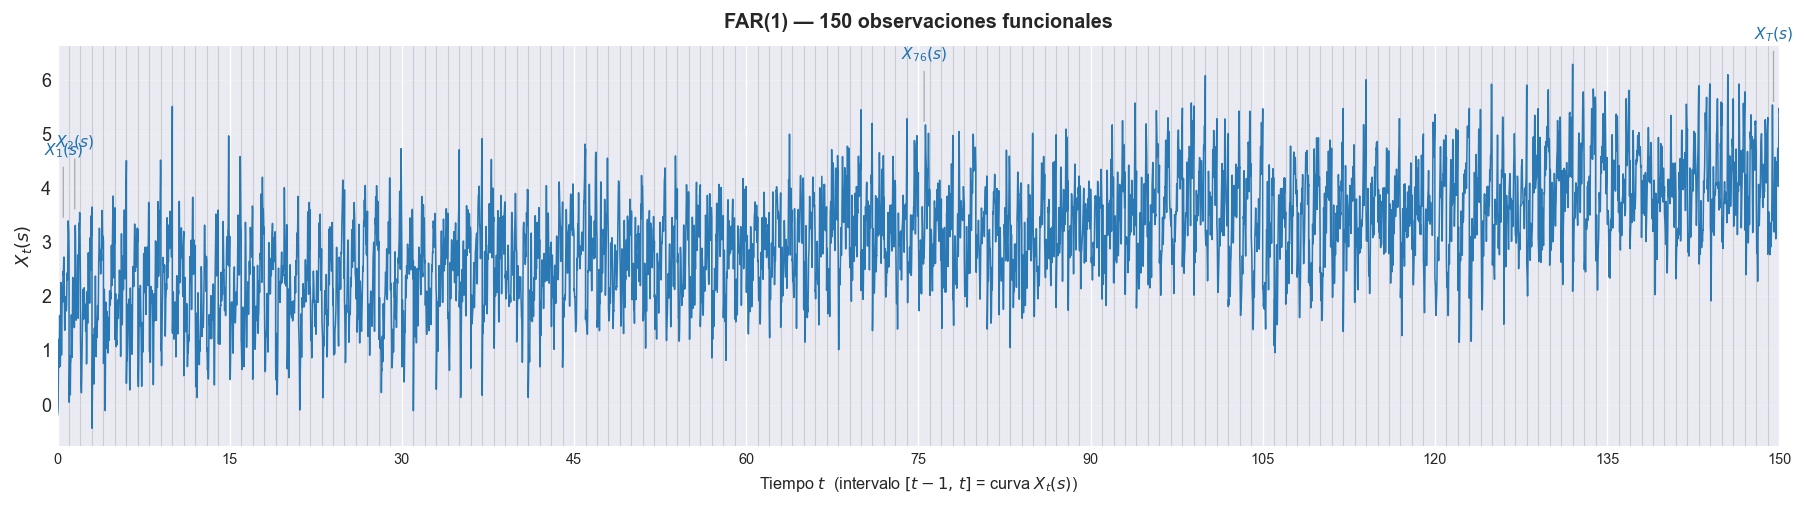

In [58]:
# ── 2.1 Dominio y operador Ψ ──────────────────────────────────────────────────
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])
Psi    = build_integral_matrix(
    domain, gaussian_integral_kernel,
    bandwidth = FAR_PARAMS["bandwidth"],
    decay     = FAR_PARAMS["decay"],
)

# ── 2.2 Simulación FAR(1) ─────────────────────────────────────────────────────
sim = FARSimulator(
    domain       = domain,
    n_curves     = FAR_PARAMS["n_curves"],
    Psi          = Psi,
    trend        = "linear",
    trend_params = {
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std    = FAR_PARAMS["noise_std"],
    noise_type   = FAR_PARAMS["noise_type"],
    burn_in      = FAR_PARAMS["burn_in"],
    random_state = SEED,
)
X   = sim.simulate()    # (T, G)
T, G = X.shape
print(f"Datos simulados : {X.shape}  →  T={T} curvas, G={G} puntos")

fig = plot_functional_time_series(
    X, domain.grid,
    highlight_idx  = [0, 1, sim.n_curves // 2, sim.n_curves - 1],
    title          = f"FAR(1) — {sim.n_curves} observaciones funcionales",
)
plt.show()


## 3. Representacion Funcional 

In [59]:
# ── 3.1 Representación funcional: B-spline → FPCA ────────────────────────────
fr    = FunctionalRepresentation(
    method       = "bspline+fpca",
    n_basis      = REPRE_PARAMS["n_basis"],
    n_basis_fpca = K_fpca,
    order        = REPRE_PARAMS["order"]
)
THETA = fr.fit_transform(X, domain.grid)   # (T, K_fpca)

print(f"\nScores THETA : {THETA.shape}")
print(f"  θ_{{t,1}} — rango : [{THETA[:,0].min():.3f}, {THETA[:,0].max():.3f}]")
for k in range(K_fpca):
    print(f"  FPC {k+1}: mean={THETA[:,k].mean():.4f}  std={THETA[:,k].std():.4f}")

# ── 3.2 Varianza explicada por componente ─────────────────────────────────────
evr    = fr.fpca_explained_variance()
cumvar = np.cumsum(evr)
print("\nVarianza explicada:")
for j, (v, c) in enumerate(zip(evr, cumvar), 1):
    print(f"  FPC {j}: {v*100:.2f}%   acumulada: {c*100:.2f}%")


Scores THETA : (150, 3)
  θ_{t,1} — rango : [-10.151, 8.478]
  FPC 1: mean=0.0000  std=3.1303
  FPC 2: mean=-0.0000  std=1.9378
  FPC 3: mean=0.0000  std=1.4636

Varianza explicada:
  FPC 1: 53.83%   acumulada: 53.83%
  FPC 2: 20.63%   acumulada: 74.46%
  FPC 3: 11.77%   acumulada: 86.23%


## 4. Transformar a data frame
En este paso debemos hacer X_t|x_t-1, con cada componente. Por tanto tendremos 3 modelos uno para cada coef del FPCA.

In [60]:
# THETA shape: (T, K_fpca)
# Para componente k:
#   col 0 → y: θ_{t,  k}  (respuesta,  fila actual)
#   col 1 → x: θ_{t-1,k}  (covariable, rezago)
# Se pierde la primera observación → T-1 filas por DataFrame

dfs = {}
for k in range(K_fpca):
    dfs[k] = pd.DataFrame({
        f"theta_{k+1}":      THETA[1:,  k],
        f"theta_{k+1}_lag1": THETA[:-1, k],
    })
    print(f"FPC {k+1}: {dfs[k].shape}")

display(dfs[0].head())

FPC 1: (149, 2)
FPC 2: (149, 2)
FPC 3: (149, 2)


,theta_1,theta_1_lag1
0,1.977945,1.478580
1,1.811226,1.977945
2,1.825804,1.811226
3,-2.386960,1.825804
4,-2.343641,-2.386960


## 5. Ajustar modelo

In [61]:
models = {}
for k in range(K_fpca):
    print(f"\n{'='*50}")
    print(f"  Ajustando PSBP-FD — FPC {k+1}")
    print(f"{'='*50}\n")

    m = PSBP_FD_v1(
        mcmc_cfg      = MCMC_CONFIG,
        hp            = HYPERPARAMS,
        seed          = SEED,
        verbose_every = 200,
    )
    m.fit(dfs[k])
    models[k] = m
    print(f"  [OK] FPC {k+1} ajustado")


  Ajustando PSBP-FD — FPC 1



  iter 200/2000
  iter 400/2000
  iter 600/2000
  iter 800/2000
  iter 1000/2000
  iter 1200/2000
  iter 1400/2000
  iter 1600/2000
  iter 1800/2000
  iter 2000/2000
  [OK] FPC 1 ajustado

  Ajustando PSBP-FD — FPC 2

  iter 200/2000


C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\models\psbp_fd_v1\functions\sampler.py:73: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return rng.multivariate_normal(mu.ravel(), cov)


  iter 400/2000
  iter 600/2000
  iter 800/2000
  iter 1000/2000
  iter 1200/2000
  iter 1400/2000
  iter 1600/2000
  iter 1800/2000
  iter 2000/2000
  [OK] FPC 2 ajustado

  Ajustando PSBP-FD — FPC 3

  iter 200/2000
  iter 400/2000
  iter 600/2000
  iter 800/2000
  iter 1000/2000
  iter 1200/2000
  iter 1400/2000
  iter 1600/2000
  iter 1800/2000
  iter 2000/2000
  [OK] FPC 3 ajustado


## 6. Evaluar modelo en base a los coeficientes del FPCA
Se utilizan los mismo valores con lo que se entreno. Se compara thetas reales versus thetas predichos 

FPC 1:
  inRMSE        : 2.768098
  P(γ=1 | data) : 1.0000

FPC 2:
  inRMSE        : 0.660907
  P(γ=1 | data) : 1.0000

FPC 3:
  inRMSE        : 1.435786
  P(γ=1 | data) : 0.1117



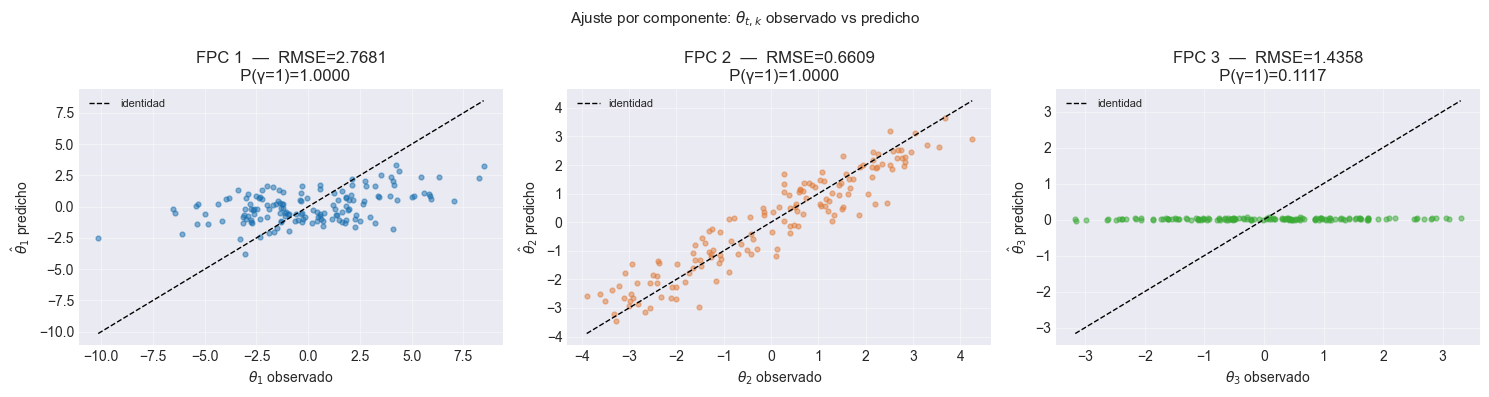

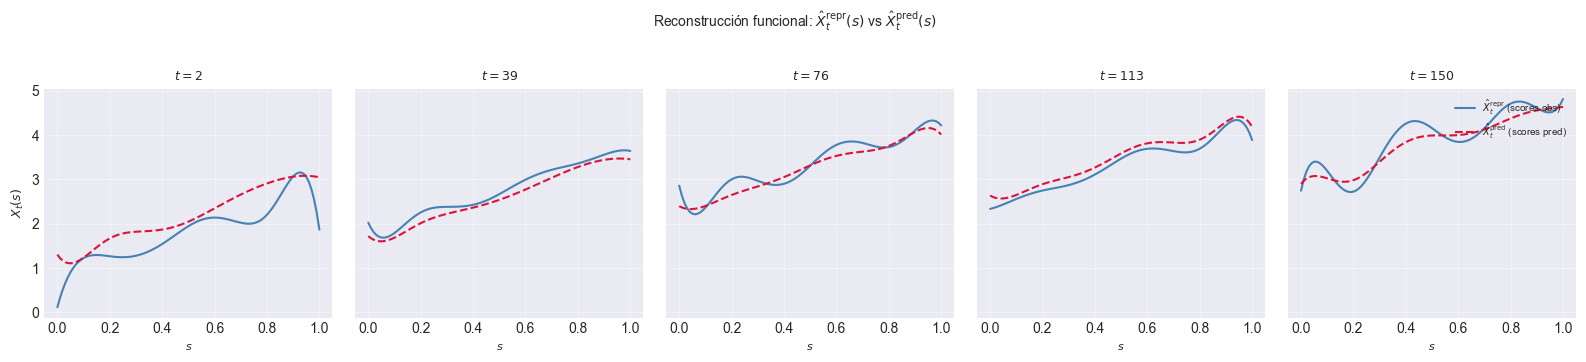

In [69]:
# ── Evaluación ────────────────────────────────────────────────────────────────
eval_results = {}
for k in range(K_fpca):
    in_rmse = models[k].rmse(dfs[k])
    in_pred = models[k].predict(dfs[k])
    y_obs   = dfs[k].iloc[:, 0].to_numpy()
    incl    = models[k].inclusion_probs(as_series=True)

    eval_results[k] = {
        "rmse":  in_rmse,
        "y_hat": in_pred,
        "y_obs": y_obs,
        "incl":  incl.values[0],
    }
    print(f"FPC {k+1}:")
    print(f"  inRMSE        : {in_rmse:.6f}")
    print(f"  P(γ=1 | data) : {incl.values[0]:.4f}")
    print()

# ── Gráfico 1: RMSE por componente θ_k ───────────────────────────────────────
fig, axes = plt.subplots(1, K_fpca, figsize=(5 * K_fpca, 4))
colors = ["#1a6faf", "#e07b39", "#3aaa35"]

for k, ax in enumerate(axes):
    y_obs = eval_results[k]["y_obs"]
    y_hat = eval_results[k]["y_hat"]

    ax.scatter(y_obs, y_hat, s=12, alpha=0.5, color=colors[k])

    # línea identidad
    lims = [min(y_obs.min(), y_hat.min()), max(y_obs.max(), y_hat.max())]
    ax.plot(lims, lims, "k--", lw=1.0, label="identidad")

    ax.set_xlabel(rf"$\theta_{{{k+1}}}$ observado")
    ax.set_ylabel(rf"$\hat{{\theta}}_{{{k+1}}}$ predicho")
    ax.set_title(
        rf"FPC {k+1}  —  RMSE={eval_results[k]['rmse']:.4f}"
        f"\n  P(γ=1)={eval_results[k]['incl']:.4f}"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(r"Ajuste por componente: $\theta_{t,k}$ observado vs predicho", fontsize=11)
plt.tight_layout()
plt.show()

# ── Gráfico 2: 5 curvas en espacio S ─────────────────────────────────────────
THETA_obs  = np.column_stack([eval_results[k]["y_obs"] for k in range(K_fpca)])  # (T-1, K)
THETA_pred = np.column_stack([eval_results[k]["y_hat"] for k in range(K_fpca)])  # (T-1, K)

# Ambas pasan por fr.reconstruct() — comparación en espacio funcional suavizado
X_obs_rec  = fr.reconstruct(THETA_obs)   # (T-1, G)
X_pred_rec = fr.reconstruct(THETA_pred)  # (T-1, G)

t_indices = np.linspace(0, T - 2, 5, dtype=int)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
fig.suptitle(
    r"Reconstrucción funcional: $\hat{X}_t^{\mathrm{repr}}(s)$ vs $\hat{X}_t^{\mathrm{pred}}(s)$",
    fontsize=10, y=1.02
)

for i, (ax, t_idx) in enumerate(zip(axes, t_indices)):
    ax.plot(domain.grid, X_obs_rec[t_idx],  color="steelblue", lw=1.5,
            label=r"$\hat{X}_t^{\mathrm{repr}}$ (scores obs)")
    ax.plot(domain.grid, X_pred_rec[t_idx], color="crimson",   lw=1.5,
            ls="--", label=r"$\hat{X}_t^{\mathrm{pred}}$ (scores pred)")
    ax.set_title(f"$t = {t_idx + 2}$", fontsize=9)
    ax.set_xlabel("$s$", fontsize=8)
    ax.grid(True, alpha=0.35)
    if i == 0:
        ax.set_ylabel("$X_t(s)$", fontsize=9)
    if i == 4:
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

## 7. Evaluar modelo vs los empiricos que se obstuvieron 
De la representacion funcional puedo generar la curva y comparar punto a punto

RMSE medio (todas las curvas) : 0.557037
RMSE máx                      : 0.829578
RMSE mín                      : 0.422279


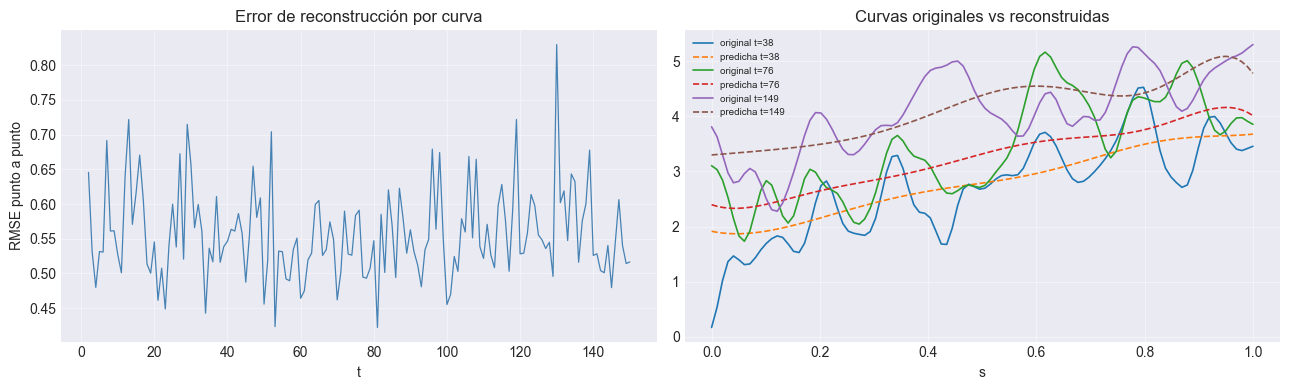

In [70]:
# Para cada observación t, reconstruir la curva predicha desde los scores
# y comparar contra X_t(s) original.
#
# fr.reconstruct(THETA_hat) invierte las dos etapas:
#   scores → coef B-spline → curva en grilla
#
# Usamos las predicciones in-sample de cada modelo para armar THETA_hat (T-1, K)

THETA_hat = np.zeros((T - 1, K_fpca))
for k in range(K_fpca):
    THETA_hat[:, k] = models[k].predict(dfs[k])

# Reconstruir curvas predichas (T-1, G)
X_hat = fr.reconstruct(THETA_hat)

# Curvas originales alineadas (descartamos t=0 porque el rezago consume esa obs)
X_orig = X[1:, :]   # (T-1, G)

# Error punto a punto por observación: RMSE_t = sqrt(mean_s (X_t(s) - X_hat_t(s))^2)
rmse_t = np.sqrt(np.mean((X_orig - X_hat) ** 2, axis=1))   # (T-1,)

print(f"RMSE medio (todas las curvas) : {rmse_t.mean():.6f}")
print(f"RMSE máx                      : {rmse_t.max():.6f}")
print(f"RMSE mín                      : {rmse_t.min():.6f}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) RMSE por observación en el tiempo
axes[0].plot(np.arange(2, T + 1), rmse_t, color="steelblue", lw=0.9)
axes[0].set_xlabel("t")
axes[0].set_ylabel("RMSE punto a punto")
axes[0].set_title("Error de reconstrucción por curva")
axes[0].grid(True, alpha=0.4)

# (b) Curva original vs reconstruida para t seleccionados
for t_show in [T // 4, T // 2, T - 2]:
    idx = t_show - 1          # ajuste por el rezago
    axes[1].plot(domain.grid, X_orig[idx], lw=1.2, label=f"original t={t_show+1}")
    axes[1].plot(domain.grid, X_hat[idx],  lw=1.2, ls="--", label=f"predicha t={t_show+1}")

axes[1].set_xlabel("s")
axes[1].set_title("Curvas originales vs reconstruidas")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 8. Pesistencia de Resultados 

[OK] Scores → data\simulaciones\processed\predict\ar1_scores_FAR_lineal_st_1_20260511_023042_scores.npz
[OK] Trazas FPC 1 → data\simulaciones\processed\predict\ar1_scores_FAR_lineal_st_1_20260511_023042_traces_fpc1.npz
[OK] Trazas FPC 2 → data\simulaciones\processed\predict\ar1_scores_FAR_lineal_st_1_20260511_023042_traces_fpc2.npz
[OK] Trazas FPC 3 → data\simulaciones\processed\predict\ar1_scores_FAR_lineal_st_1_20260511_023042_traces_fpc3.npz
[OK] Fig scatter → reports\simulaciones\ar1_scores_FAR_lineal_st_1_20260511_023042\ar1_scores_FAR_lineal_st_1_20260511_023042_scatter_thetas.png


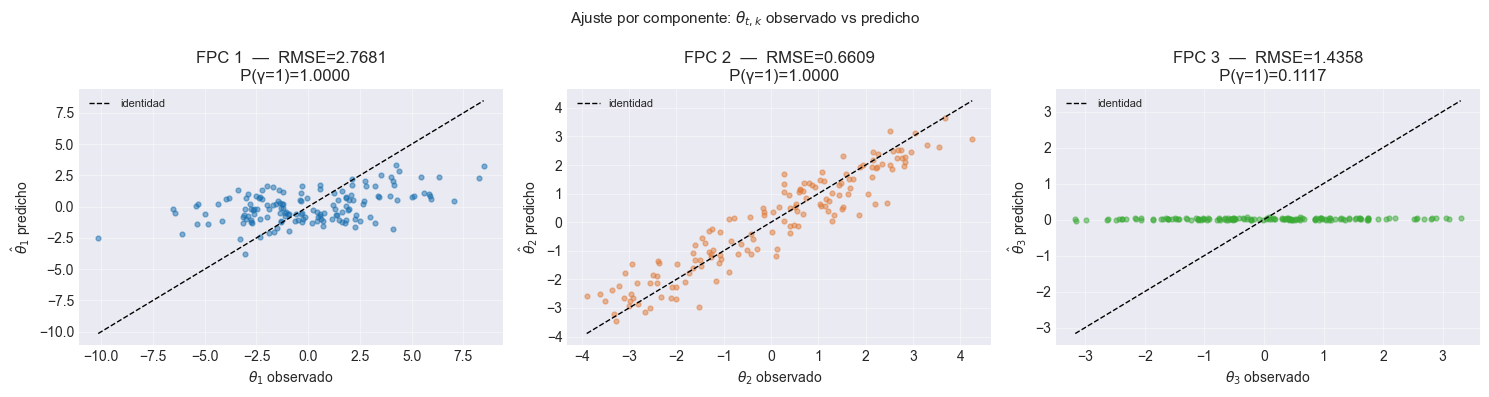

[OK] Fig curvas  → reports\simulaciones\ar1_scores_FAR_lineal_st_1_20260511_023042\ar1_scores_FAR_lineal_st_1_20260511_023042_curvas_reconstruidas.png


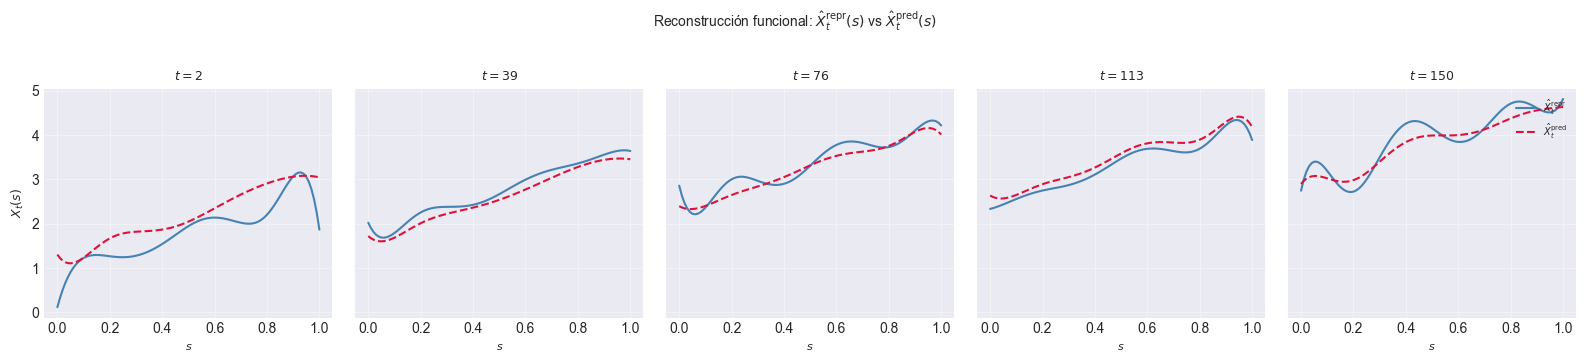

[OK] Fig trazas FPC 1 → reports\simulaciones\ar1_scores_FAR_lineal_st_1_20260511_023042\ar1_scores_FAR_lineal_st_1_20260511_023042_trazas_fpc1.png


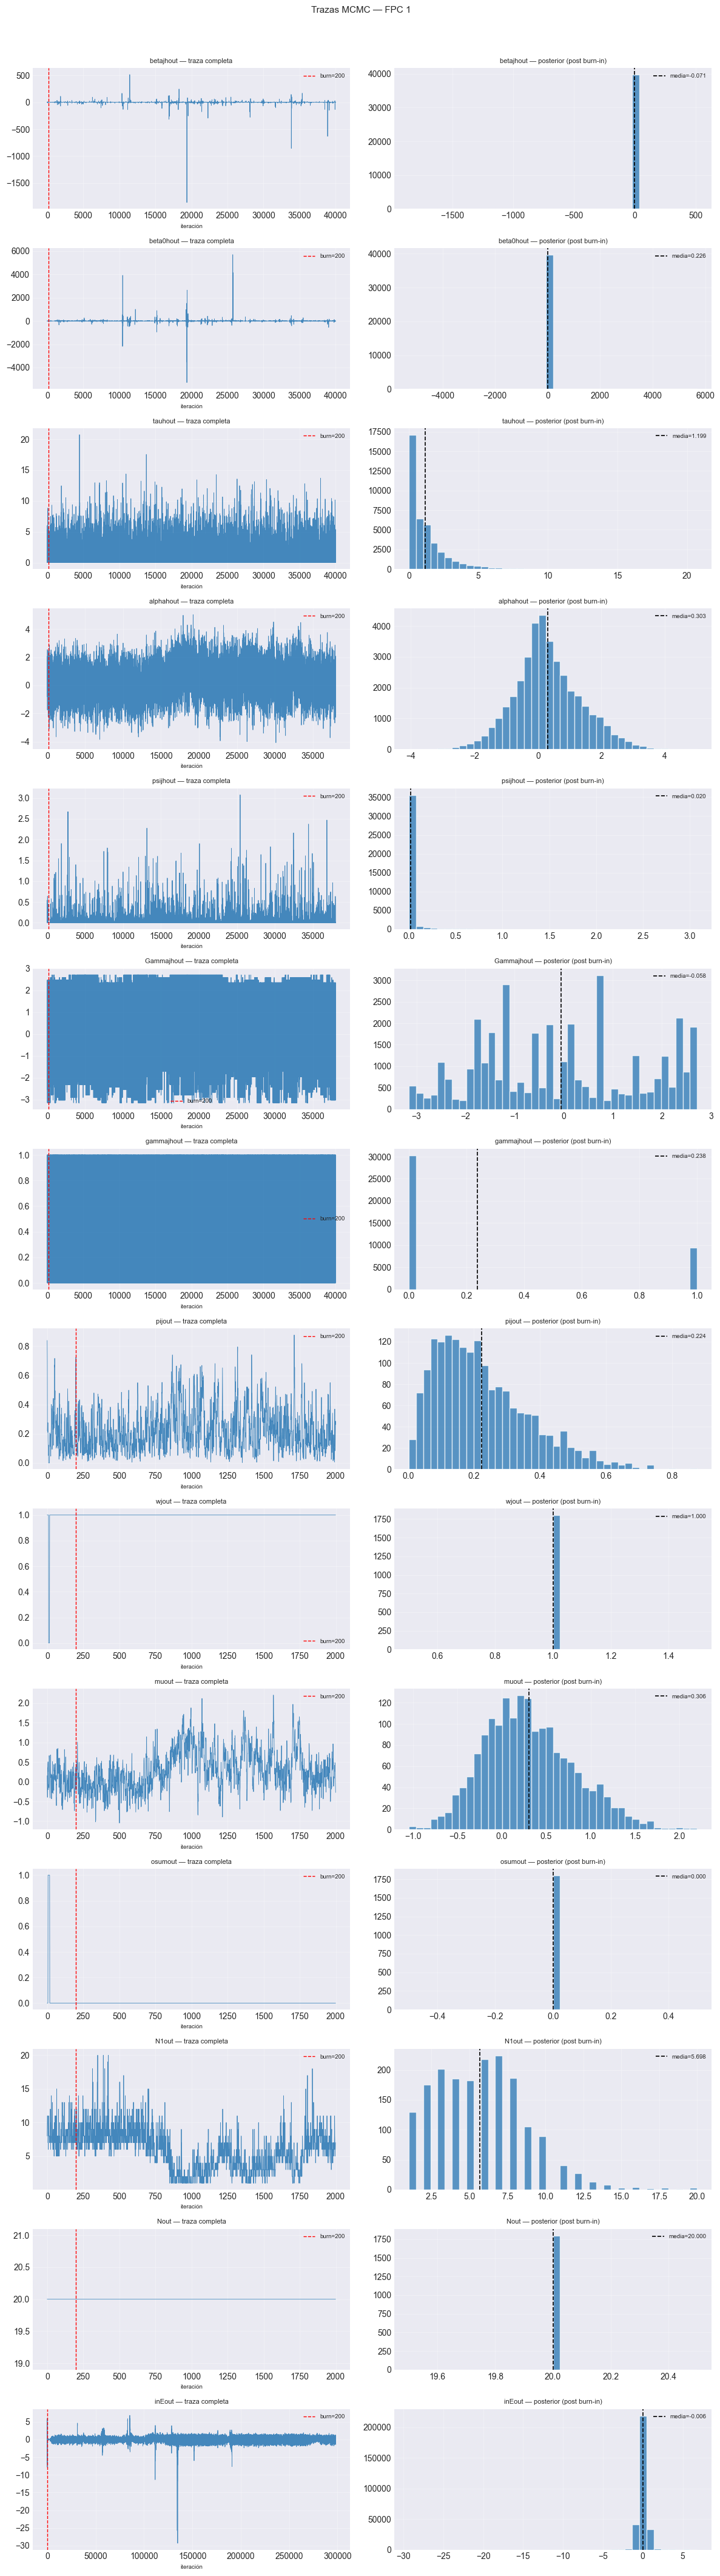

[OK] Fig trazas FPC 2 → reports\simulaciones\ar1_scores_FAR_lineal_st_1_20260511_023042\ar1_scores_FAR_lineal_st_1_20260511_023042_trazas_fpc2.png


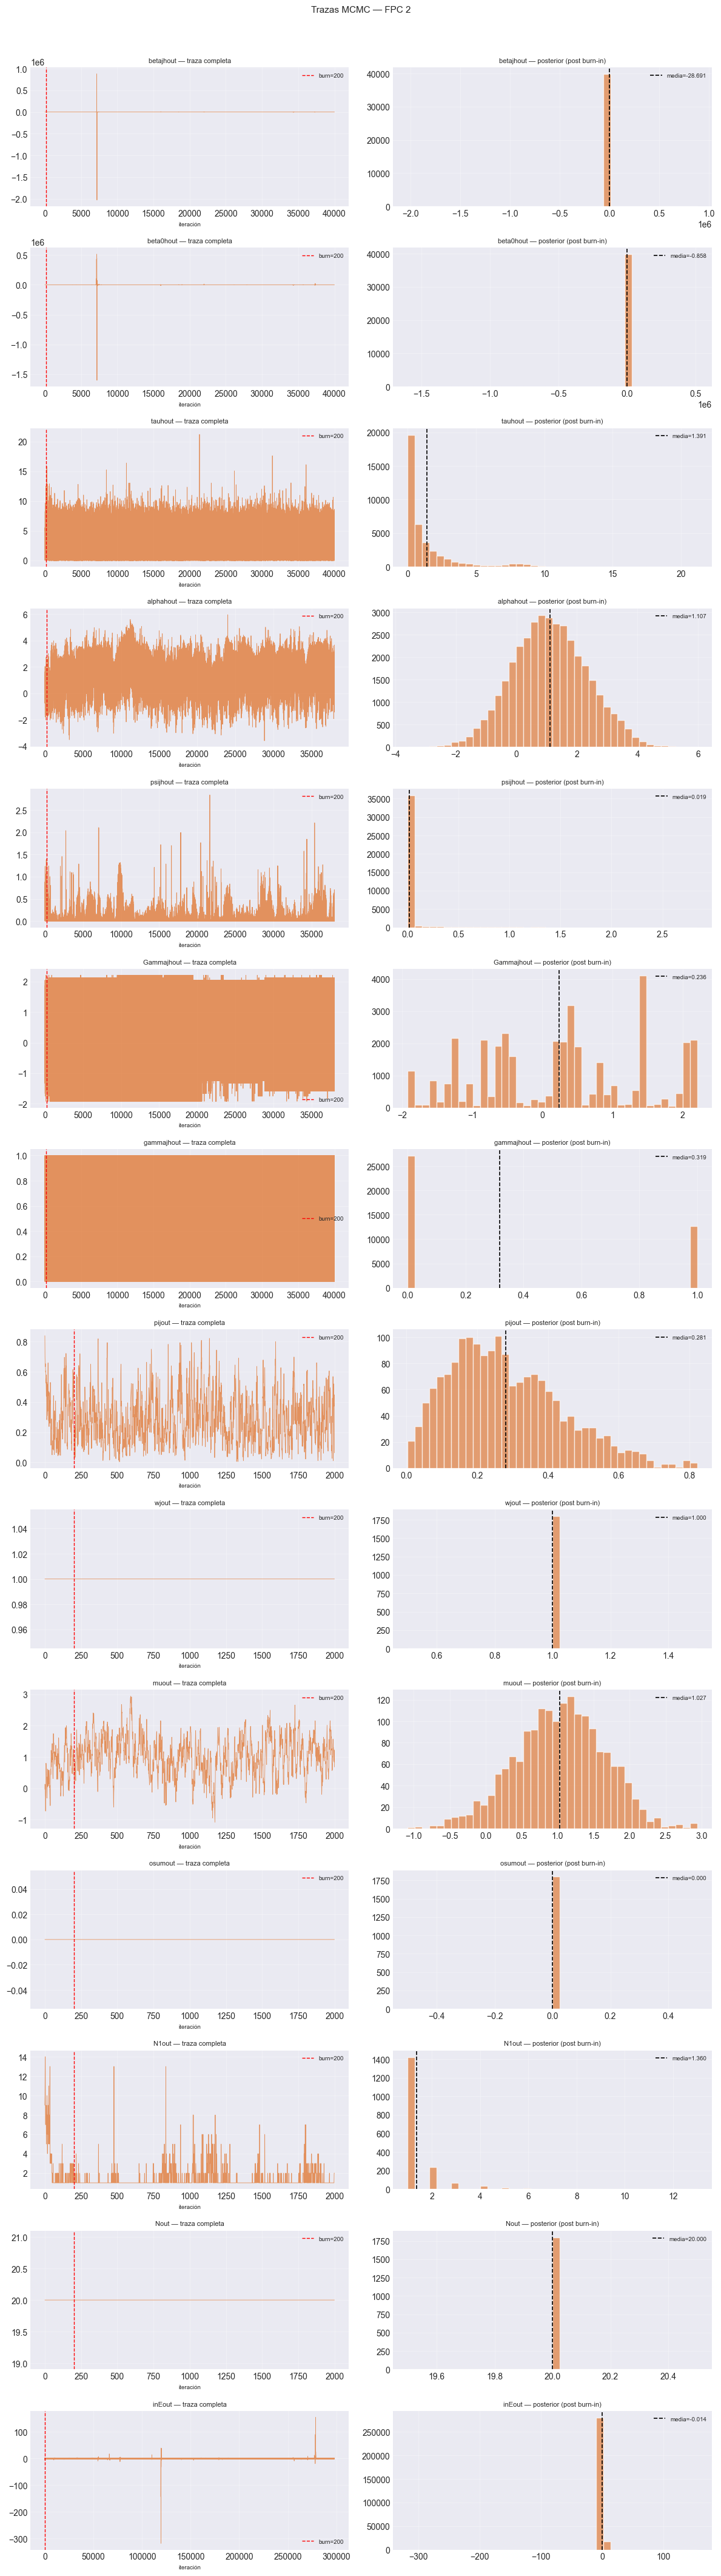

[OK] Fig trazas FPC 3 → reports\simulaciones\ar1_scores_FAR_lineal_st_1_20260511_023042\ar1_scores_FAR_lineal_st_1_20260511_023042_trazas_fpc3.png


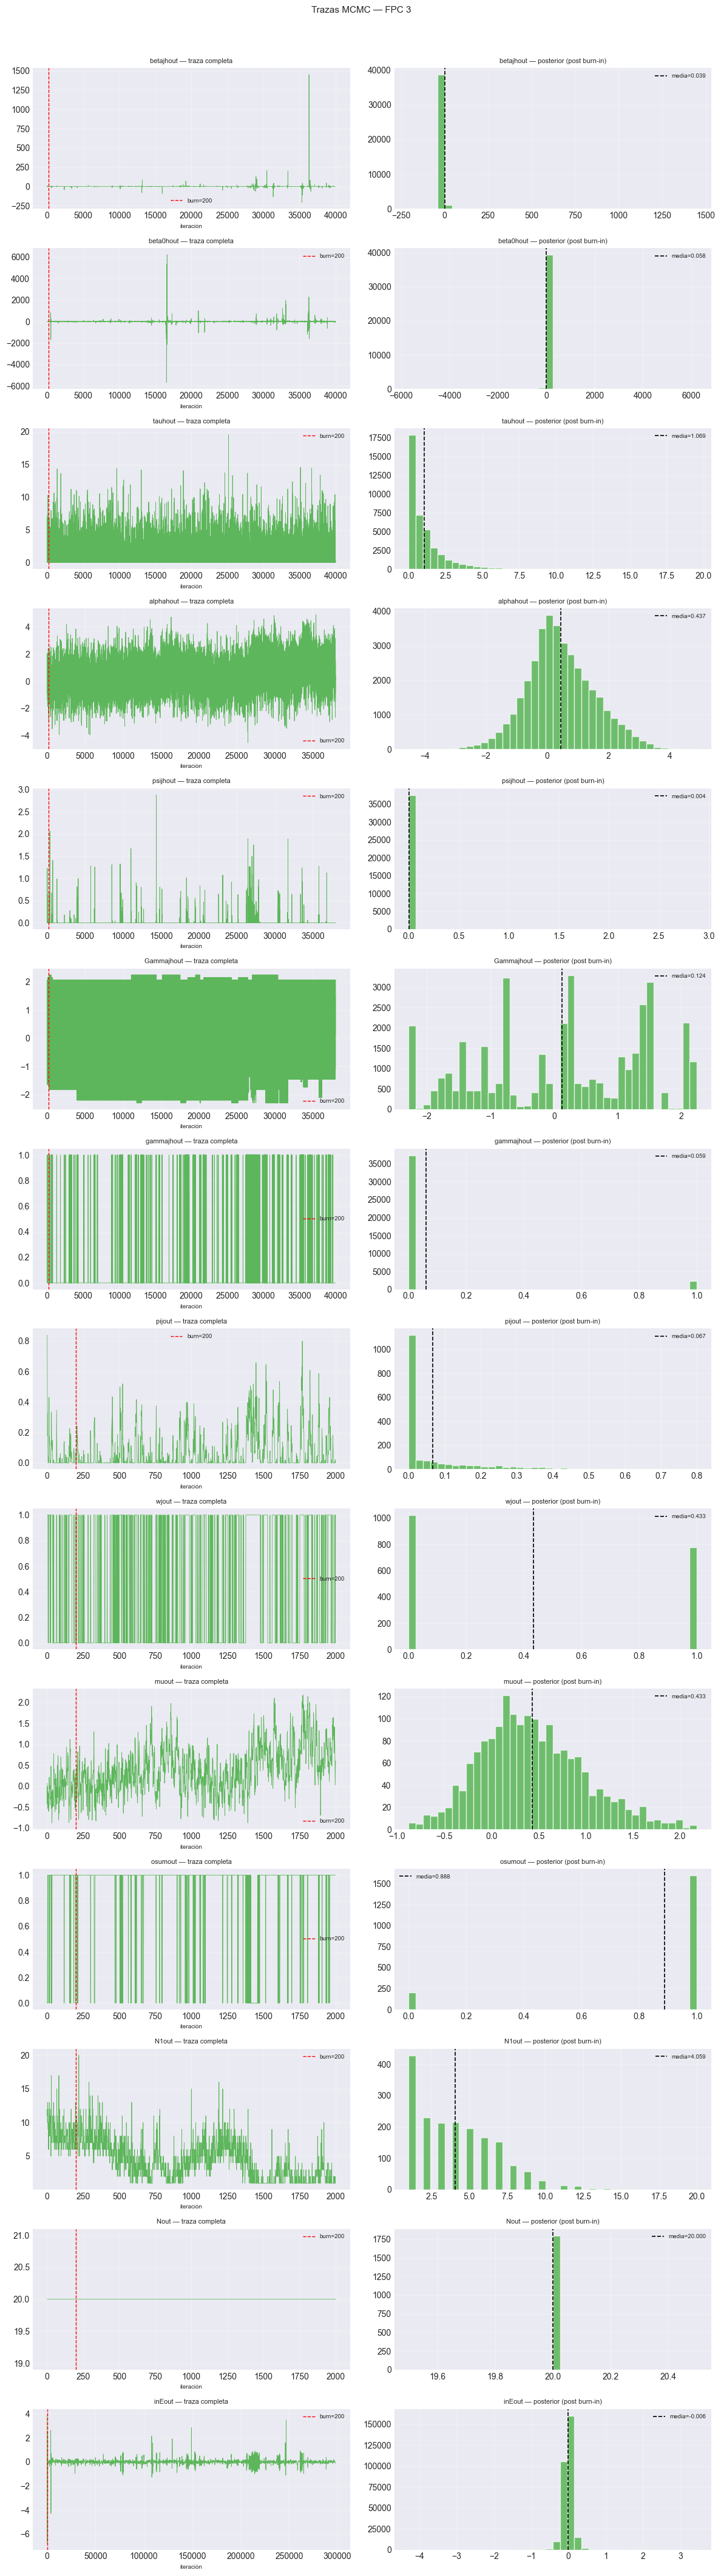


  RESUMEN: ar1_scores_FAR_lineal_st_1_20260511_023042
  FPC        RMSE    P(γ=1)    Converge
  ----------------------------------------
  FPC 1    2.7681    1.0000           ✓
  FPC 2    0.6609    1.0000           ✓
  FPC 3    1.4358    0.1117   ⚠ revisar


In [73]:
# ══════════════════════════════════════════════════════════════════
# 8. Persistencia de resultados
# ══════════════════════════════════════════════════════════════════

PATHS["predict"].mkdir(parents=True, exist_ok=True)
(PATHS["reports"] / EXPERIMENT_ID).mkdir(parents=True, exist_ok=True)

# ── 8.1 Scores observados y predichos → .npz ─────────────────────
path_scores = PATHS["predict"] / f"{EXPERIMENT_ID}_scores.npz"

np.savez_compressed(
    path_scores,
    THETA      = THETA,                                                          # (T,   K) scores completos
    THETA_obs  = np.column_stack([eval_results[k]["y_obs"] for k in range(K_fpca)]),  # (T-1, K)
    THETA_pred = np.column_stack([eval_results[k]["y_hat"] for k in range(K_fpca)]),  # (T-1, K)
    X          = X,                                                              # (T,   G) curvas originales
)
print(f"[OK] Scores → {path_scores.relative_to(PROJECT_ROOT)}")

# ── 8.2 Trazas MCMC por modelo → .npz ────────────────────────────
for k in range(K_fpca):
    path_traces = PATHS["predict"] / f"{EXPERIMENT_ID}_traces_fpc{k+1}.npz"
    np.savez_compressed(path_traces, **models[k].traces)
    print(f"[OK] Trazas FPC {k+1} → {path_traces.relative_to(PROJECT_ROOT)}")


# ── 8.3 Figuras → .png ───────────────────────────────────────────
report_dir = PATHS["reports"] / EXPERIMENT_ID

# Figura 1: scatter θ observado vs predicho por componente
fig, axes = plt.subplots(1, K_fpca, figsize=(5 * K_fpca, 4))
colors = ["#1a6faf", "#e07b39", "#3aaa35"]
for k, ax in enumerate(axes):
    y_obs = eval_results[k]["y_obs"]
    y_hat = eval_results[k]["y_hat"]
    ax.scatter(y_obs, y_hat, s=12, alpha=0.5, color=colors[k])
    lims = [min(y_obs.min(), y_hat.min()), max(y_obs.max(), y_hat.max())]
    ax.plot(lims, lims, "k--", lw=1.0, label="identidad")
    ax.set_xlabel(rf"$\theta_{{{k+1}}}$ observado")
    ax.set_ylabel(rf"$\hat{{\theta}}_{{{k+1}}}$ predicho")
    ax.set_title(
        rf"FPC {k+1}  —  RMSE={eval_results[k]['rmse']:.4f}"
        f"\n  P(γ=1)={eval_results[k]['incl']:.4f}"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
plt.suptitle(r"Ajuste por componente: $\theta_{t,k}$ observado vs predicho", fontsize=11)
plt.tight_layout()
path_fig1 = report_dir / f"{EXPERIMENT_ID}_scatter_thetas.png"
fig.savefig(path_fig1, dpi=150, bbox_inches="tight")
print(f"[OK] Fig scatter → {path_fig1.relative_to(PROJECT_ROOT)}")
plt.show()

# Figura 2: reconstrucción funcional — 5 curvas
THETA_obs_mat  = np.column_stack([eval_results[k]["y_obs"] for k in range(K_fpca)])
THETA_pred_mat = np.column_stack([eval_results[k]["y_hat"] for k in range(K_fpca)])
X_obs_rec  = fr.reconstruct(THETA_obs_mat)
X_pred_rec = fr.reconstruct(THETA_pred_mat)
t_indices  = np.linspace(0, T - 2, 5, dtype=int)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
fig.suptitle(
    r"Reconstrucción funcional: $\hat{X}_t^{\mathrm{repr}}(s)$ vs $\hat{X}_t^{\mathrm{pred}}(s)$",
    fontsize=10, y=1.02
)
for i, (ax, t_idx) in enumerate(zip(axes, t_indices)):
    ax.plot(domain.grid, X_obs_rec[t_idx],  color="steelblue", lw=1.5,
            label=r"$\hat{X}_t^{\mathrm{repr}}$")
    ax.plot(domain.grid, X_pred_rec[t_idx], color="crimson",   lw=1.5,
            ls="--", label=r"$\hat{X}_t^{\mathrm{pred}}$")
    ax.set_title(f"$t = {t_idx + 2}$", fontsize=9)
    ax.set_xlabel("$s$", fontsize=8)
    ax.grid(True, alpha=0.35)
    if i == 0:
        ax.set_ylabel("$X_t(s)$", fontsize=9)
    if i == 4:
        ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
path_fig2 = report_dir / f"{EXPERIMENT_ID}_curvas_reconstruidas.png"
fig.savefig(path_fig2, dpi=150, bbox_inches="tight")
print(f"[OK] Fig curvas  → {path_fig2.relative_to(PROJECT_ROOT)}")
plt.show()

# Figura 3: trazas MCMC por modelo
for k in range(K_fpca):
    traces = models[k].traces
    trace_keys = list(traces.keys())
    n_traces = len(trace_keys)

    fig, axes = plt.subplots(n_traces, 2, figsize=(12, 3 * n_traces))
    fig.suptitle(f"Trazas MCMC — FPC {k+1}", fontsize=11, y=1.01)

    for i, key in enumerate(trace_keys):
        trace = np.array(traces[key]).ravel()
        burn  = MCMC_CONFIG["burn"]

        # Traza completa con línea de burn-in
        axes[i, 0].plot(trace, lw=0.6, color=colors[k], alpha=0.8)
        axes[i, 0].axvline(burn, color="red", lw=1.0, ls="--", label=f"burn={burn}")
        axes[i, 0].set_title(f"{key} — traza completa", fontsize=8)
        axes[i, 0].set_xlabel("iteración", fontsize=7)
        axes[i, 0].legend(fontsize=7)
        axes[i, 0].grid(True, alpha=0.3)

        # Histograma post burn-in
        post = trace[burn:]
        axes[i, 1].hist(post, bins=40, color=colors[k], alpha=0.7, edgecolor="white")
        axes[i, 1].axvline(post.mean(), color="black", lw=1.2, ls="--",
                           label=f"media={post.mean():.3f}")
        axes[i, 1].set_title(f"{key} — posterior (post burn-in)", fontsize=8)
        axes[i, 1].legend(fontsize=7)
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    path_fig3 = report_dir / f"{EXPERIMENT_ID}_trazas_fpc{k+1}.png"
    fig.savefig(path_fig3, dpi=150, bbox_inches="tight")
    print(f"[OK] Fig trazas FPC {k+1} → {path_fig3.relative_to(PROJECT_ROOT)}")
    plt.show()
# ── 8.4 Resumen final ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  RESUMEN: {EXPERIMENT_ID}")
print(f"{'='*55}")
print(f"  {'FPC':<6} {'RMSE':>8}  {'P(γ=1)':>8}  {'Converge':>10}")
print(f"  {'-'*40}")
for k in range(K_fpca):
    conv = "✓" if eval_results[k]["incl"] > 0.5 else "⚠ revisar"
    print(
        f"  FPC {k+1}  "
        f"{eval_results[k]['rmse']:>8.4f}  "
        f"{eval_results[k]['incl']:>8.4f}  "
        f"{conv:>10}"
    )
print(f"{'='*55}")